### Multiple Linear Regression Assignment


## Note

Some sections of this assignment include additional images, screenshots, diagrams, and explanatory notes that I created to improve my understanding of the concepts.

These materials were incorporated as part of my learning process and to serve as future study notes. While preparing this assignment, I focused on understanding the concepts rather than only obtaining the final results.

 The supplementary visuals and explanations are included solely for educational purposes and to make the notebook easier to review and learn from later.


In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/ToyotaCorolla - MLR.csv')

In [4]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,1264
Diesel,155
CNG,17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [7]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [8]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [9]:
df.duplicated().sum()

np.int64(1)

df.drop_duplicates() → Creates a new notebook without the extra page.

df = df.drop_duplicates() → Throws away the old notebook and keeps the new one.

df.drop_duplicates(inplace=True) → Erases the duplicate page directly from the original notebook.

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.shape

(1435, 11)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

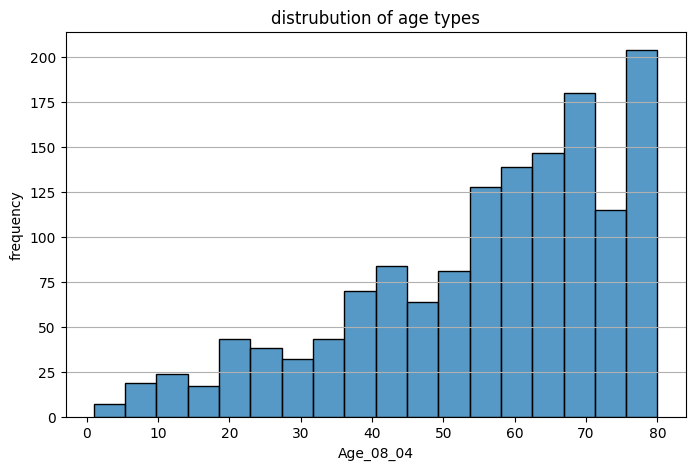

In [14]:
plt.figure(figsize = (8,5))
sns.histplot(
    data = df,
    x = "Age_08_04"
)
plt.title('distrubution of age types')
plt.ylabel('frequency')
plt.grid(axis = 'y')

plt.show()

The histogram of Age is right-skewed, indicating that most cars are relatively newer

In [15]:
columns =[
'KM',
'HP',
'cc',
'Weight',
'Price'
]

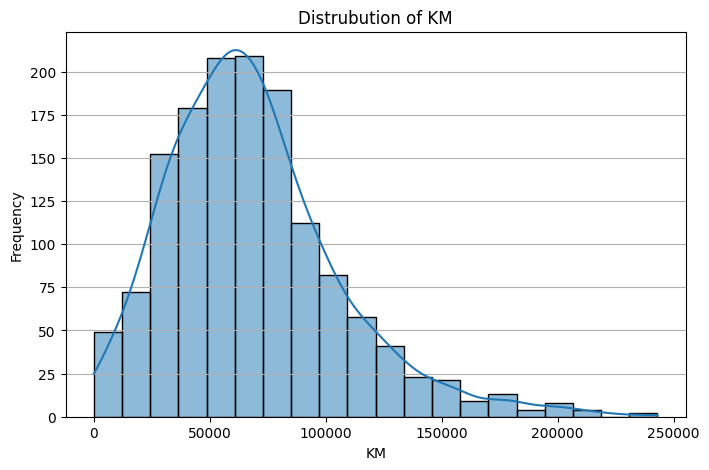

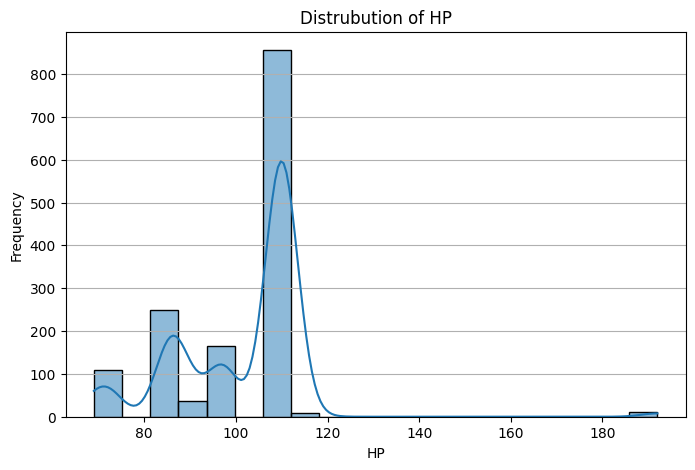

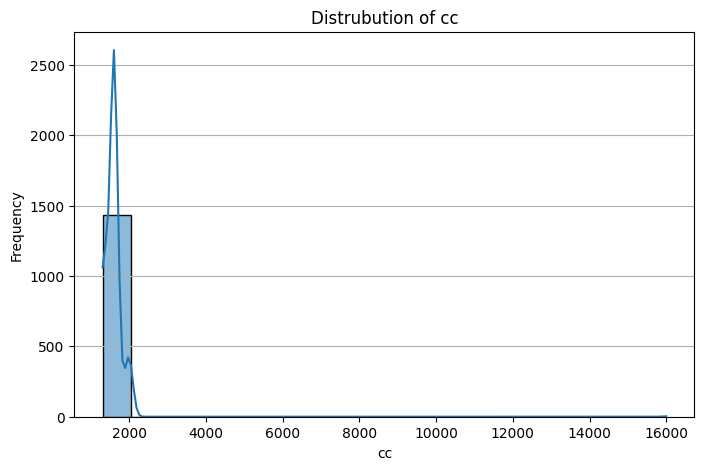

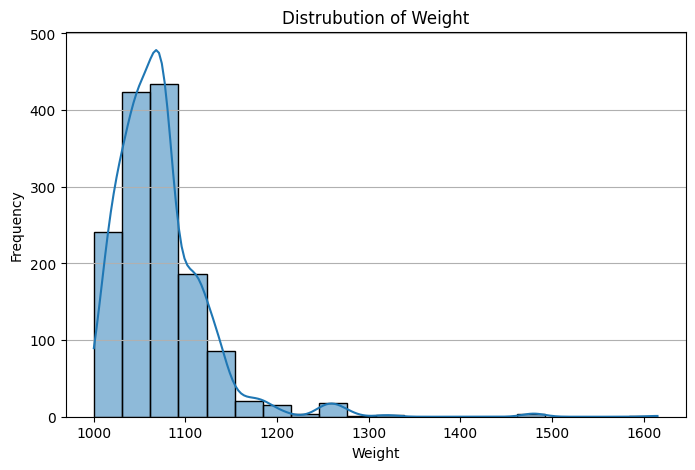

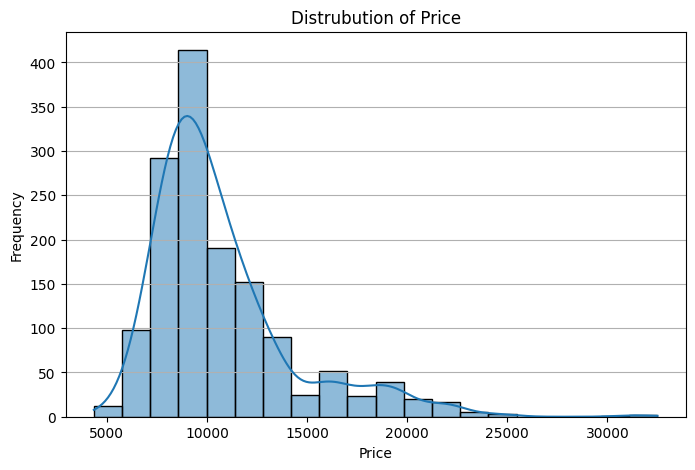

In [16]:
for col in columns :
  plt.figure(figsize=(8,5))
  sns.histplot(
      data=df,
      x = col,
      kde = True,
      bins = 20
      )
  plt.title(f'Distrubution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.grid(axis = 'y')
  plt.show()

In [17]:
num_columns =[
'Age_08_04',
'KM',
'HP',
'cc',
'Weight',
'Price'
]

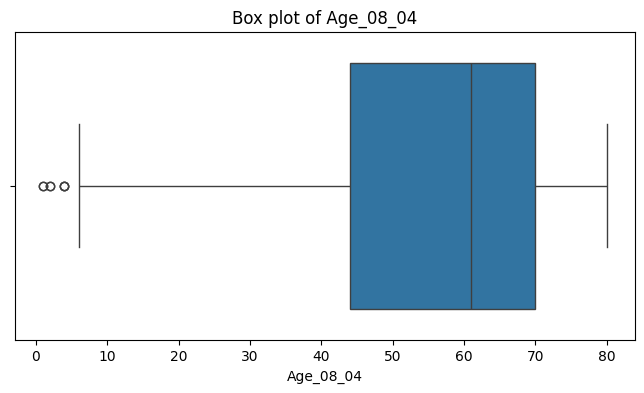

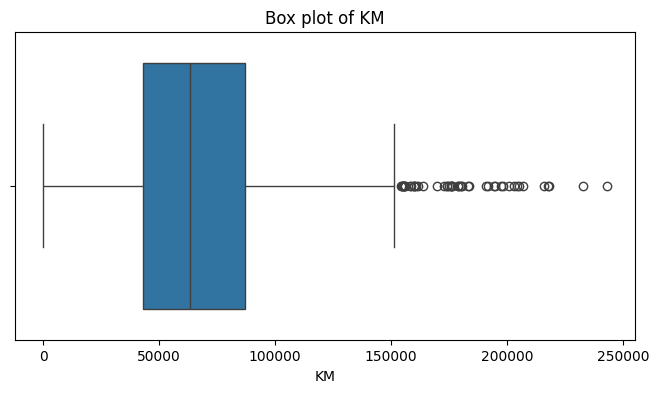

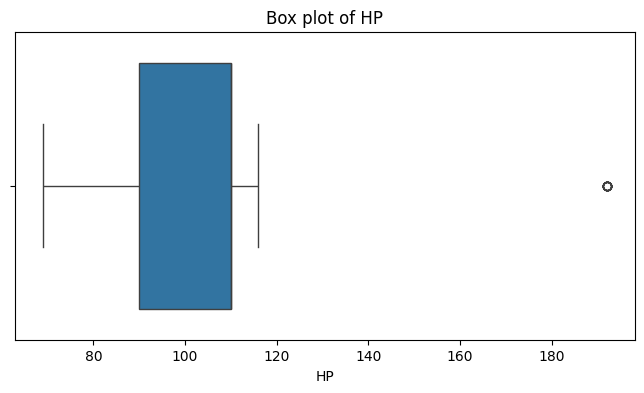

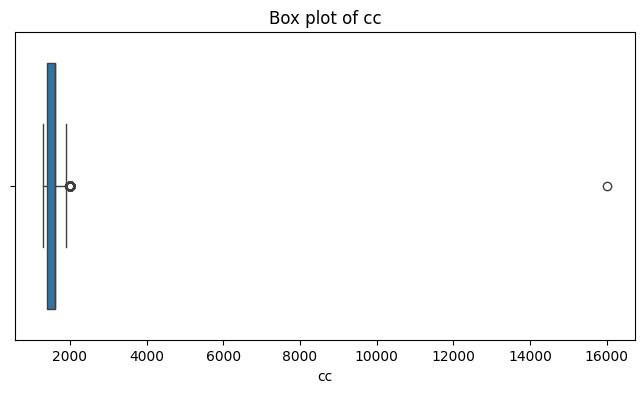

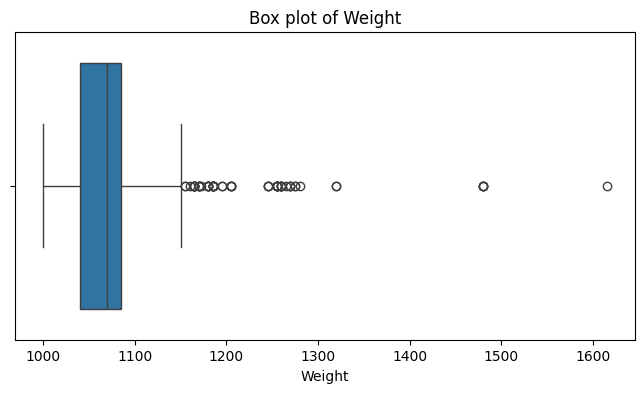

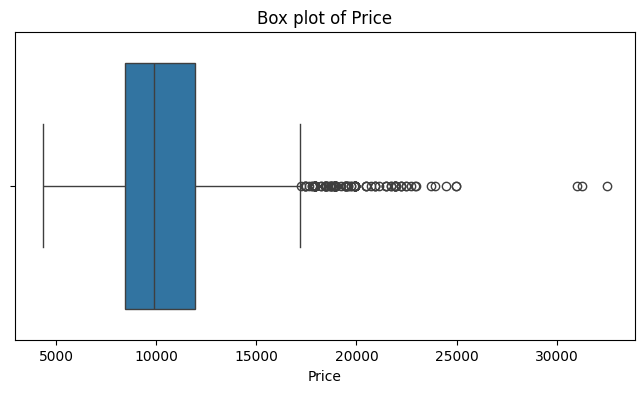

In [18]:
for cols in num_columns :
  plt.figure(figsize = (8,4))
  sns.boxplot(
      data = df,
      x =cols
  )
  plt.title(f'Box plot of {cols}')
  plt.xlabel(cols)
  plt.show()

The boxplot of Price shows a few high-priced outliers.

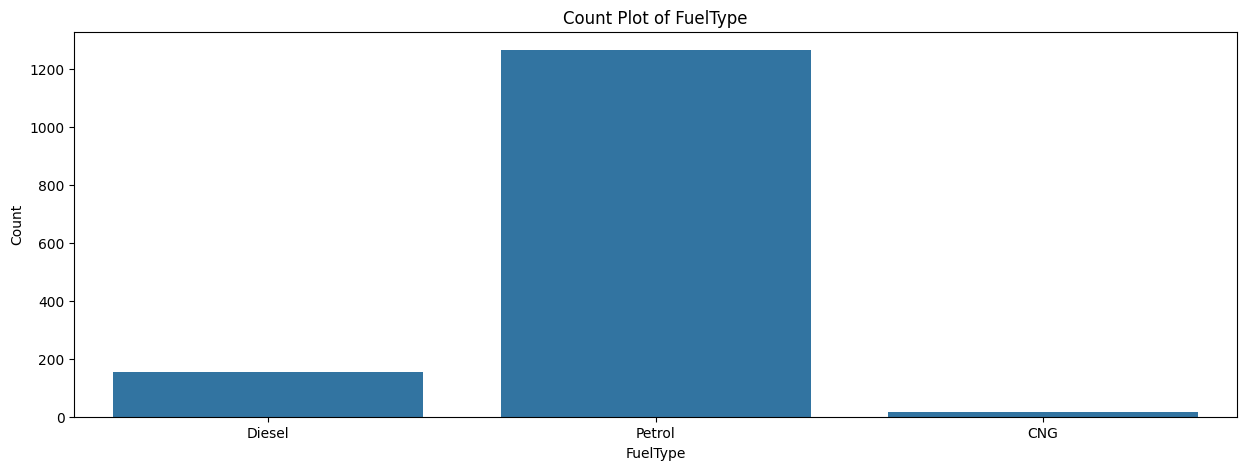

In [19]:
plt.figure(figsize=(15,5))

sns.countplot(
    data=df,
    x='Fuel_Type',
)

plt.title('Count Plot of FuelType')
plt.xlabel('FuelType')
plt.ylabel('Count')
plt.show()

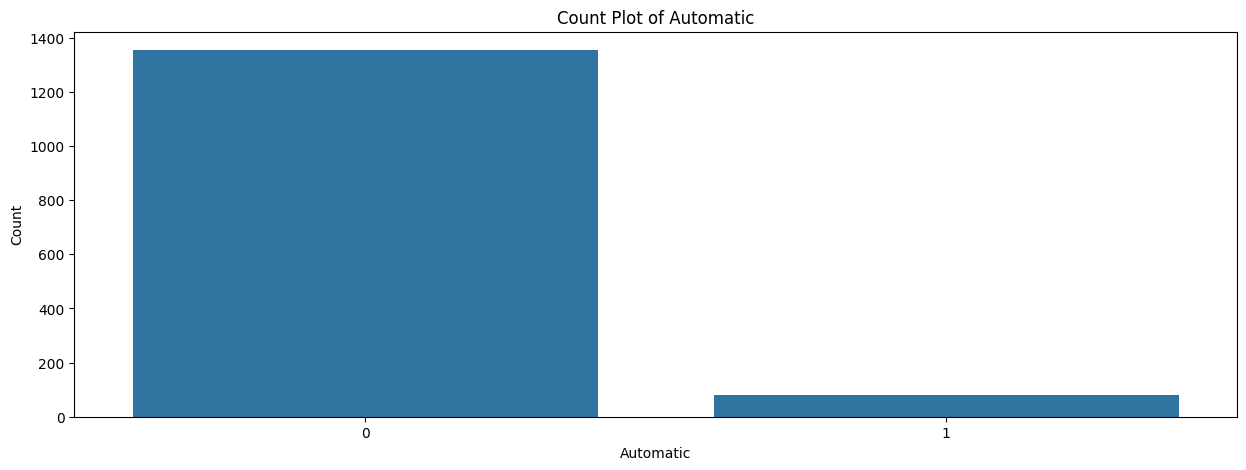

In [20]:
plt.figure(figsize=(15,5))

sns.countplot(
    data=df,
    x='Automatic',
)

plt.title('Count Plot of Automatic')
plt.xlabel('Automatic')
plt.ylabel('Count')
plt.show()

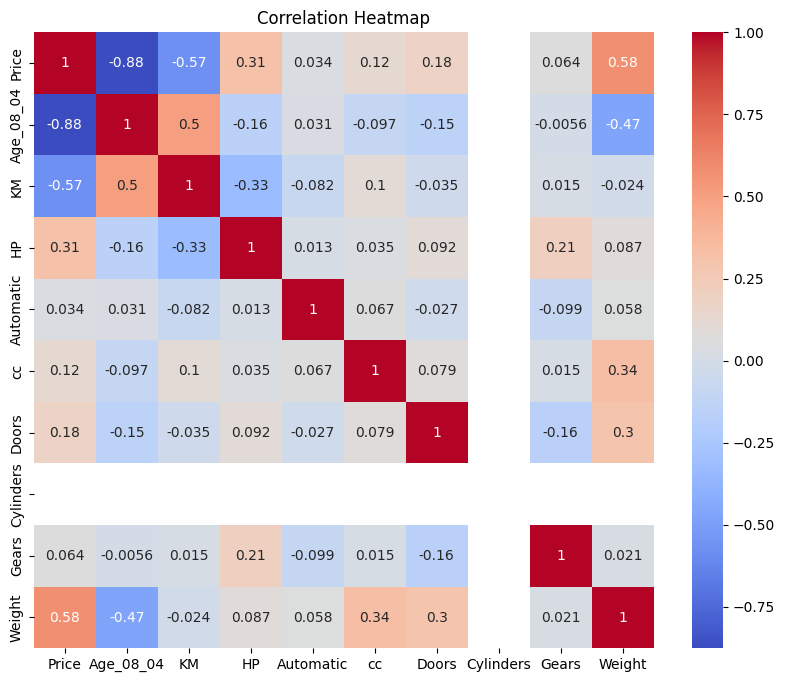

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm'
            )
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that Age has a strong negative correlation with Price, while Weight has a positive correlation.

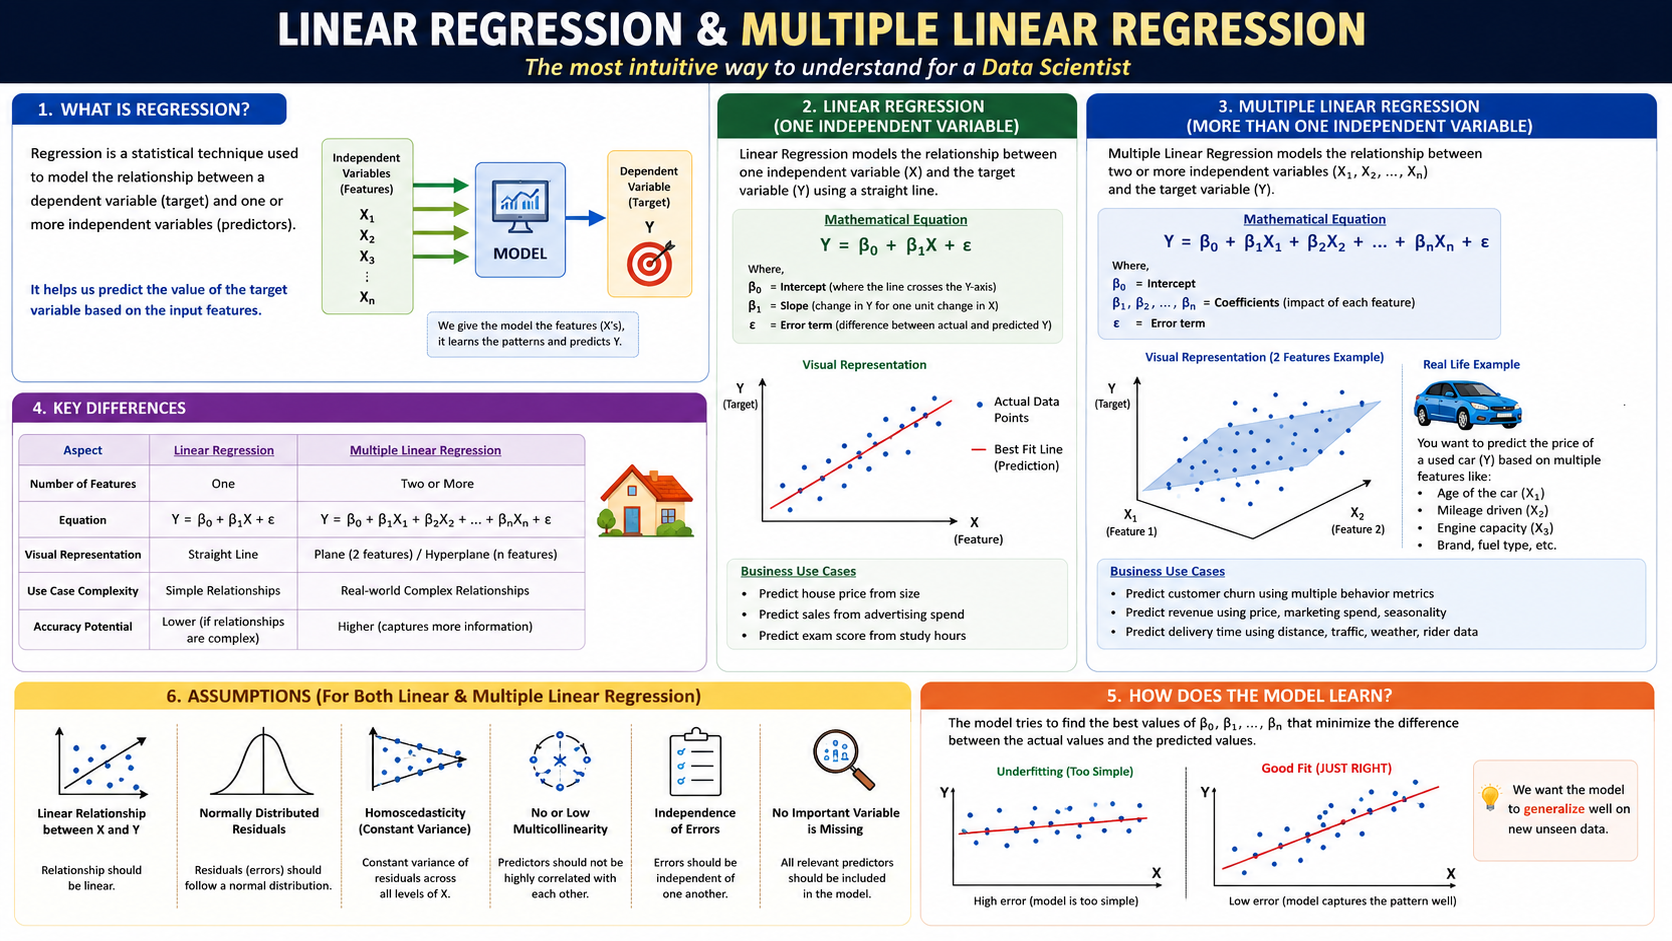

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,root_mean_squared_error

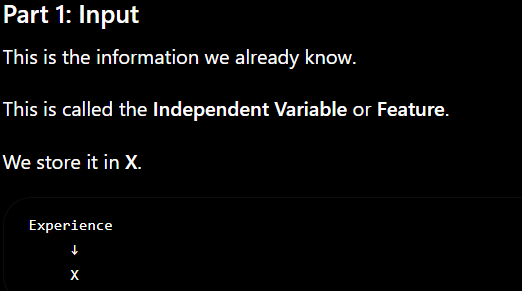

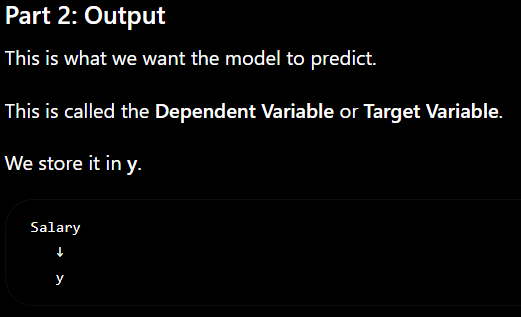

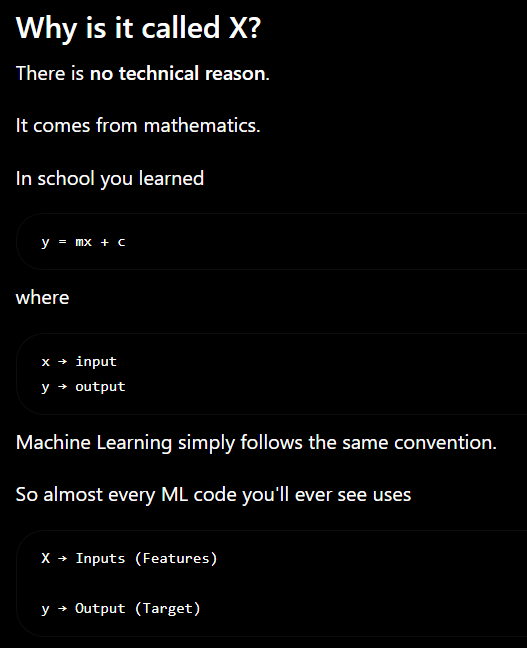

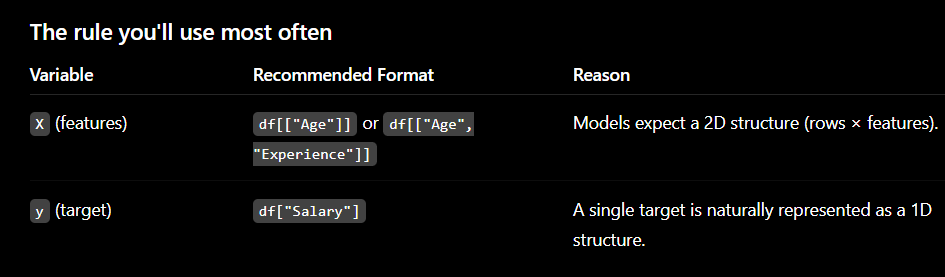

In [23]:
X = df[['Age_08_04']]  # Independent Variable
y = df['Price']  # Dependent Variable

In [65]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.20, # we can tell 20 percent of data out of 100
    random_state = 42
)

In [25]:
model = LinearRegression() # initialisation of the model
model

LinearRegression()

In [66]:
model.fit(X_train,y_train) # fiting of the data
# we are using X_train,y_train to train

LinearRegression()

In [27]:
y_pred = model.predict(X_test) # for the predivtion we are using the X_test

In [28]:
y_pred

array([10183.54420222,  9671.55821547, 10183.54420222,  8476.92424639,
        9159.57222872,  8818.24823755,  8647.58624197,  7282.29027731,
       13255.46012272, 13767.44610947,  8647.58624197,  8647.58624197,
       13255.46012272, 13255.46012272,  7452.95227289, 11719.50216247,
       12743.47413597, 16498.0380388 , 10354.2061978 , 12231.48814922,
       12914.13613155, 18375.31999021,  8476.92424639, 11036.85418014,
        8476.92424639, 15303.40406971,  7282.29027731,  9330.2342243 ,
       15474.0660653 , 13255.46012272,  7794.27626406, 10354.2061978 ,
        9671.55821547, 10183.54420222,  9159.57222872,  7964.93825964,
        9159.57222872, 10012.88220664, 16498.0380388 , 10524.86819339,
       10354.2061978 ,  9159.57222872,  8818.24823755,  8135.60025522,
        9671.55821547, 17351.34801671, 10012.88220664,  6770.30429056,
       10524.86819339, 13255.46012272, 13255.46012272,  6599.64229497,
       15132.74207413, 15132.74207413,  7623.61426847,  8988.91023314,
      

In [67]:
# evaluation metrics
mae = mean_absolute_error(y_test, y_pred) # as for the evaluvation we use the y_test and y_pred value

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 1152.0266262290684
MSE : 2748095.6146516902
RMSE : 1657.7381019484621
R2 Score : 0.770937319953073


In [30]:
model.coef_ #slope

array([-170.66199558])

In [31]:
model.intercept_

np.float64(20252.6019416261)

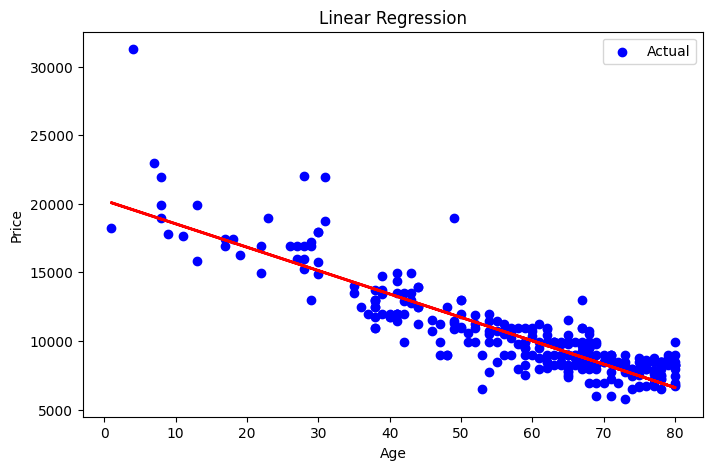

In [32]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, color='blue', label='Actual')

plt.plot(X_test, y_pred, color='red', linewidth=2)

plt.title("Linear Regression")

plt.xlabel("Age")

plt.ylabel("Price")

plt.legend()

plt.show()


In [33]:
#model 1
X1 = df[["Age_08_04","KM"]]

y = df["Price"]

In [34]:
X_train1, X_test1, y_train, y_test = train_test_split(

    X1,

    y,

    test_size=0.20,

    random_state=42
)

In [35]:
model1 = LinearRegression()

model1.fit(X_train1,y_train)

LinearRegression()

In [36]:
prediction1 = model1.predict(X_test1)

In [37]:
prediction1

array([10049.19486021,  9854.65284638,  9208.93565482,  9155.27154545,
        9696.55540168,  8933.84398651,  9520.33737818,  7837.85815599,
       13292.87203142, 13996.70571009,  8452.49455182,  9036.21789249,
       13367.15114859, 13762.95612026,  8080.24987395, 12091.55292064,
       13040.40857912, 15380.84249409, 10836.84818518, 12806.23521524,
       13074.94759632, 18660.81013185,  9120.92889566, 11517.36724643,
        8196.28779952, 15625.25687679,  7668.29767926,  8379.15346296,
       15666.03384815, 13685.4732712 ,  7823.83552865, 10483.08160022,
        9749.50602671, 10222.29808808,  9934.10618853,  7843.67806146,
        9135.9531737 , 10056.64337684, 16564.86721663, 10828.17919927,
        9769.92071079,  9438.71431285,  9202.99136725,  8247.83281345,
       10105.47623678, 17235.63243037, 10776.2795339 ,  7674.33640333,
       10956.12506334, 13754.90441313, 13677.25205445,  7074.19462425,
       14887.08341102, 15666.75987685,  7028.60512349,  8306.19365817,
      

In [38]:
print("MAE")

print(mean_absolute_error(y_test,prediction1))

print()

print("MSE")

print(mean_squared_error(y_test,prediction1))

print()

print("RMSE")

print(np.sqrt(mean_squared_error(y_test,prediction1)))

print()

print("R2 Score")

print(r2_score(y_test,prediction1))

MAE
1081.8744460328119

MSE
2546307.7262356803

RMSE
1595.7154277112445

R2 Score
0.7877569947399126


In [39]:
X2 = df[
    [
        "Age_08_04",
        "KM",
        "HP",
        "Weight"
    ]
]

In [40]:
X_train2,X_test2,y_train,y_test = train_test_split(

    X2,

    y,

    test_size=0.20,

    random_state=42
)

In [41]:
model2 = LinearRegression()

model2.fit(X_train2,y_train)

LinearRegression()

In [42]:
prediction2 = model2.predict(X_test2)

In [43]:
prediction2

array([10243.69576594, 10394.12981236,  9441.81883844,  9495.15626069,
        8442.87609011,  8355.89530439,  8118.80975922,  8360.49766157,
       11787.77082014, 12438.92937962,  9396.05661885,  9392.63261808,
       13277.35515636, 12344.45309492,  9082.96430265, 11606.82939627,
       12365.81321322, 17450.28988832, 12088.22327589, 11576.1551075 ,
       11651.25687509, 18008.31933884,  9950.68704512, 10475.30052362,
        7306.30383392, 16016.0284966 ,  7106.49487489,  8465.34593082,
       15495.07758186, 13952.03809447,  8161.55750279, 10889.90793793,
       10170.3730061 , 10150.96781947, 10174.35424843,  8620.47728157,
        8931.44669067, 10015.57454707, 16194.82407756, 10746.90723772,
        8600.50992269,  9587.70202427,  9727.8307452 ,  8542.10672891,
       10691.15951162, 17491.44779507, 10013.05485895,  8850.19069596,
       10898.42309702, 12843.37977164, 12937.64073455,  6249.09946281,
       14694.18626596, 16225.19521557,  5830.4429245 ,  8103.54179436,
      

In [44]:
print(mean_absolute_error(y_test,prediction2))  # we are directly printing instead of using some variables

print(mean_squared_error(y_test,prediction2))

print(np.sqrt(mean_squared_error(y_test,prediction2)))

print(r2_score(y_test,prediction2))

987.225283393743
1934478.8193824275
1390.8554272038584
0.8387549179514566


In [45]:
X3 = df.drop("Price",axis=1)
X3 = pd.get_dummies(X3, columns=['Fuel_Type'], drop_first=True)

In [46]:
X_train3,X_test3,y_train,y_test = train_test_split(

    X3,

    y,

    test_size=0.20,

    random_state=42
)

In [50]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)             # we are converting the fuel_type(petrol,diesel,cng) in to 0's and 1's for the training of the model

encoded = encoder.fit_transform(df[["Fuel_Type"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Fuel_Type"])
)

df = pd.concat([df, encoded_df], axis=1)

df.drop("Fuel_Type", axis=1, inplace=True)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train) # there is a difference between the fit and the fit_transform

X_test = scaler.transform(X_test)

In [53]:
model3 = LinearRegression()

model3.fit(X_train3,y_train)

LinearRegression()

In [54]:
prediction3 = model3.predict(X_test3)

In [55]:
print(mean_absolute_error(y_test,prediction3))

print(mean_squared_error(y_test,prediction3))

print(np.sqrt(mean_squared_error(y_test,prediction3)))

print(r2_score(y_test,prediction3))

986.4966877482506
2155628.3561396236
1468.205828942122
0.8203213869961808


In [56]:
# the main purpose of using the dataframe is to show data in a 2d format which is more organised for clear understanding
coefficient = pd.DataFrame({

    "Feature":X3.columns,

    "Coefficient":model3.coef_

})

coefficient

,Feature,Coefficient
0,Age_08_04,-1.212292e+02
1,KM,-1.599715e-02
2,HP,1.607544e+01
3,Automatic,2.688222e+02
4,cc,-4.710949e-02
5,Doors,-8.809716e+01
6,Cylinders,1.136868e-13
7,Gears,4.550119e+02
8,Weight,2.636120e+01
9,Fuel_Type_Diesel,-3.896838e+02


A negative coefficient for Age means older cars generally have lower prices.

A negative coefficient for KM means cars with higher mileage tend to be cheaper.

A positive coefficient for HP means more powerful cars tend to have higher prices.

In [58]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)

ridge.fit(X_train3,y_train)

ridge_prediction = ridge.predict(X_test3)

In [59]:
print(mean_absolute_error(y_test,ridge_prediction))

print(mean_squared_error(y_test,ridge_prediction))

print(np.sqrt(mean_squared_error(y_test,ridge_prediction)))

print(r2_score(y_test,ridge_prediction))

986.892601661389
2152506.133638209
1467.1421654489416
0.8205816343653275


In [61]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)

lasso.fit(X_train3,y_train)

lasso_prediction = lasso.predict(X_test3)

In [62]:
print(mean_absolute_error(y_test,lasso_prediction))

print(mean_squared_error(y_test,lasso_prediction))

print(np.sqrt(mean_squared_error(y_test,lasso_prediction)))

print(r2_score(y_test,lasso_prediction))

986.4225238543949
2154744.0166619574
1467.9046347300487
0.8203950995590717


In [69]:
# the main purpose of using the dataframe is to show data in a 2d format which is more organised for clear understanding
# you can check that the scores and the names of the model organised clearly
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression Model 1",

        "Linear Regression Model 2",

        "Linear Regression Model 3",

        "Ridge Regression",

        "Lasso Regression"

    ],

    "R2 Score":[

        r2_score(y_test,prediction1),

        r2_score(y_test,prediction2),

        r2_score(y_test,prediction3),

        r2_score(y_test,ridge_prediction),

        r2_score(y_test,lasso_prediction)

    ]

})

comparison

,Model,R2 Score
0,Linear Regression Model 1,0.787757
1,Linear Regression Model 2,0.838755
2,Linear Regression Model 3,0.820321
3,Ridge Regression,0.820582
4,Lasso Regression,0.820395


Model 2 achieved a higher R² score than Model 1 because it uses additional features such as HP and Weight, which improve prediction accuracy.

##conclusion
Three Multiple Linear Regression models were developed using different feature combinations.

Ridge and Lasso Regression were applied to reduce overfitting and improve model generalization.

The models were evaluated using MAE, MSE, RMSE, and R² Score.

The model with the highest R² Score and the lowest error values was considered the best-performing model for predicting Toyota Corolla prices.

###1. What is Normalization & Standardization and how is it helpful?

##Normalization

Normalization and Standardization are feature scaling techniques used to bring numerical features to a similar scale before training a machine learning model.

When a dataset contains features with very different ranges, the larger values may have a greater influence on the model than the smaller values. Scaling helps ensure that each feature contributes more fairly to the learning process.

Normalization transforms data into a fixed range, usually 0 to 1.


##Standardization

Standardization transforms the data so that it has:

Mean = 0
Standard Deviation = 1

Standardization is commonly used in Linear Regression, Ridge Regression, Lasso Regression, Logistic Regression, Support Vector Machines, and Neural Networks.


##Why is it helpful?

It improves model performance.

It helps the model converge faster during training.

It prevents features with larger values from dominating smaller-valued features.

It is especially important for Ridge and Lasso Regression because they apply penalties to model coefficients.

##Conclusion

Normalization scales data between 0 and 1, while Standardization converts data to have a mean of 0 and a standard deviation of 1. In this assignment, Standardization was used before applying Ridge and Lasso Regression to improve model performance.


###2. What techniques can be used to address multicollinearity in Multiple Linear Regression?


Multicollinearity occurs when two or more independent variables are highly correlated with each other. This makes it difficult for the regression model to determine the individual effect of each feature on the target variable.

For example,

 if two variables provide almost the same information, the model may produce unstable or unreliable coefficients.

##Techniques to handle multicollinearity

####1. Remove Highly Correlated Features

Use a correlation heatmap to identify highly correlated variables.

If two variables have a correlation close to +1 or −1, one of them can be removed.

####2. Use Variance Inflation Factor (VIF)

The Variance Inflation Factor (VIF) measures how much multicollinearity exists in each feature.

VIF = 1 → No multicollinearity
VIF between 1 and 5 → Moderate multicollinearity
VIF > 5 (or sometimes >10) → High multicollinearity

Features with high VIF values are good candidates for removal.

###3. Apply Ridge Regression

Ridge Regression adds a penalty to the regression coefficients, reducing their magnitude.

This helps reduce the impact of multicollinearity without removing features from the dataset.

###4. Apply Lasso Regression

Lasso Regression also applies a penalty but can reduce some coefficients exactly to zero.

This effectively removes less important features and performs automatic feature selection.

####5. Feature Selection

Select only the most relevant independent variables using statistical methods or domain knowledge.

Removing unnecessary features can reduce multicollinearity and improve model performance.

####Conclusion

Multicollinearity can reduce the reliability of a Multiple Linear Regression model. Common techniques to address it include:

Removing highly correlated features

Using Variance Inflation Factor (VIF)

Applying Ridge Regression

Applying Lasso Regression

Performing feature selection

In this assignment, Ridge Regression and Lasso Regression were used to reduce the effects of multicollinearity and improve the stability of the regression model.